# 07 — Análise Comparativa dos Resultados

Compara as três estratégias de prompting: zero-shot, few-shot e chain-of-thought.

- Métrica principal: **F1-macro**
- Saída: `results/metrics_summary.json`

In [1]:
import json
from pathlib import Path

import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    classification_report, f1_score, precision_score, recall_score, confusion_matrix
)

CATEGORIAS = ["homophobia", "insult", "misogyny", "not_toxic", "obscene", "racism", "xenophobia"]
NOMES_DISPLAY = {"zero_shot": "Zero-Shot", "few_shot": "Few-Shot"}

In [2]:
experimentos = {
    "zero_shot": pl.read_csv("../results/zero_shot_results.csv"),
    "few_shot":  pl.read_csv("../results/few_shot_results.csv"),
}

for nome, df in experimentos.items():
    # normaliza case — predições podem ter sido salvas em maiúsculo
    experimentos[nome] = df.with_columns(
        pl.col("predicao").str.to_lowercase()
    )
    unknown = (experimentos[nome]["predicao"] == "unknown").sum()
    print(f"{nome}: {len(df)} tweets, unknown={unknown}")

zero_shot: 500 tweets, unknown=0
few_shot: 500 tweets, unknown=0


## F1-macro por estratégia

In [3]:
metricas = {}

for nome, df in experimentos.items():
    y_true = df["label"].to_list()
    y_pred = df["predicao"].to_list()
    metricas[nome] = {
        "f1_macro":  round(f1_score(y_true, y_pred, average="macro",  zero_division=0), 4),
        "f1_weighted": round(f1_score(y_true, y_pred, average="weighted", zero_division=0), 4),
        "precision_macro": round(precision_score(y_true, y_pred, average="macro", zero_division=0), 4),
        "recall_macro":    round(recall_score(y_true, y_pred,    average="macro", zero_division=0), 4),
        "per_class": {},
    }
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    for cat in CATEGORIAS:
        if cat in report:
            metricas[nome]["per_class"][cat] = {
                "f1":        round(report[cat]["f1-score"],  4),
                "precision": round(report[cat]["precision"], 4),
                "recall":    round(report[cat]["recall"],    4),
                "support":   int(report[cat]["support"]),
            }

print(f"{'Estratégia':<12} {'F1-macro':>10} {'F1-weighted':>12} {'Precision':>10} {'Recall':>8}")
print("-" * 56)
for nome, m in metricas.items():
    print(f"{nome:<12} {m['f1_macro']:>10.4f} {m['f1_weighted']:>12.4f} {m['precision_macro']:>10.4f} {m['recall_macro']:>8.4f}")

Estratégia     F1-macro  F1-weighted  Precision   Recall
--------------------------------------------------------
zero_shot        0.2673       0.7050     0.2733   0.2913
few_shot         0.2750       0.7712     0.2962   0.2868


## F1 por categoria

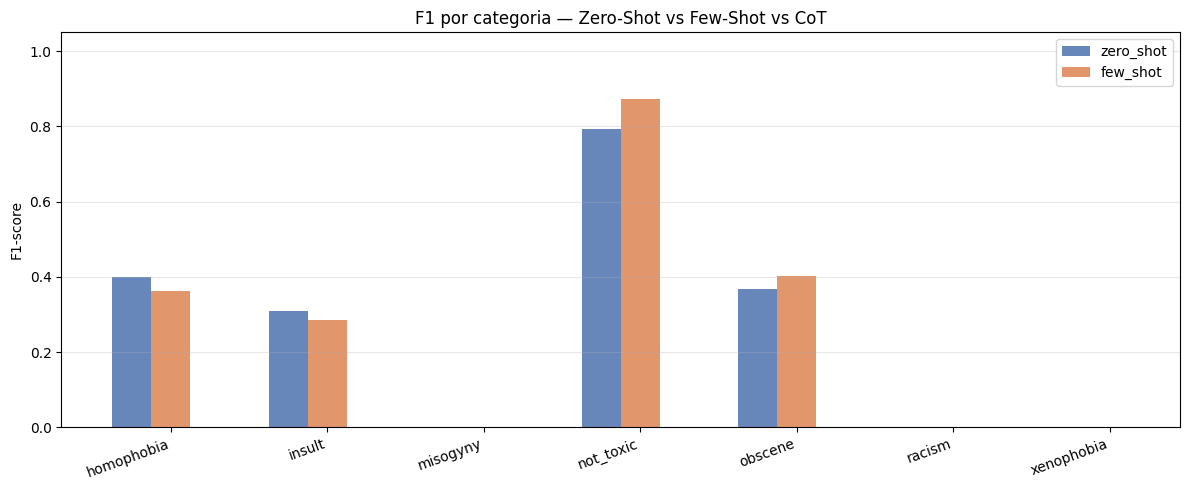

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(CATEGORIAS))
width = 0.25
cores = ["#4C72B0", "#DD8452", "#55A868"]

for idx, (nome, m) in enumerate(metricas.items()):
    f1s = [m["per_class"].get(cat, {}).get("f1", 0) for cat in CATEGORIAS]
    ax.bar(x + idx * width, f1s, width, label=nome, color=cores[idx], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(CATEGORIAS, rotation=20, ha="right")
ax.set_ylabel("F1-score")
ax.set_ylim(0, 1.05)
ax.set_title("F1 por categoria — Zero-Shot vs Few-Shot vs CoT")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../results/f1_por_categoria.png", dpi=150)
plt.show()

## Matrizes de confusão lado a lado

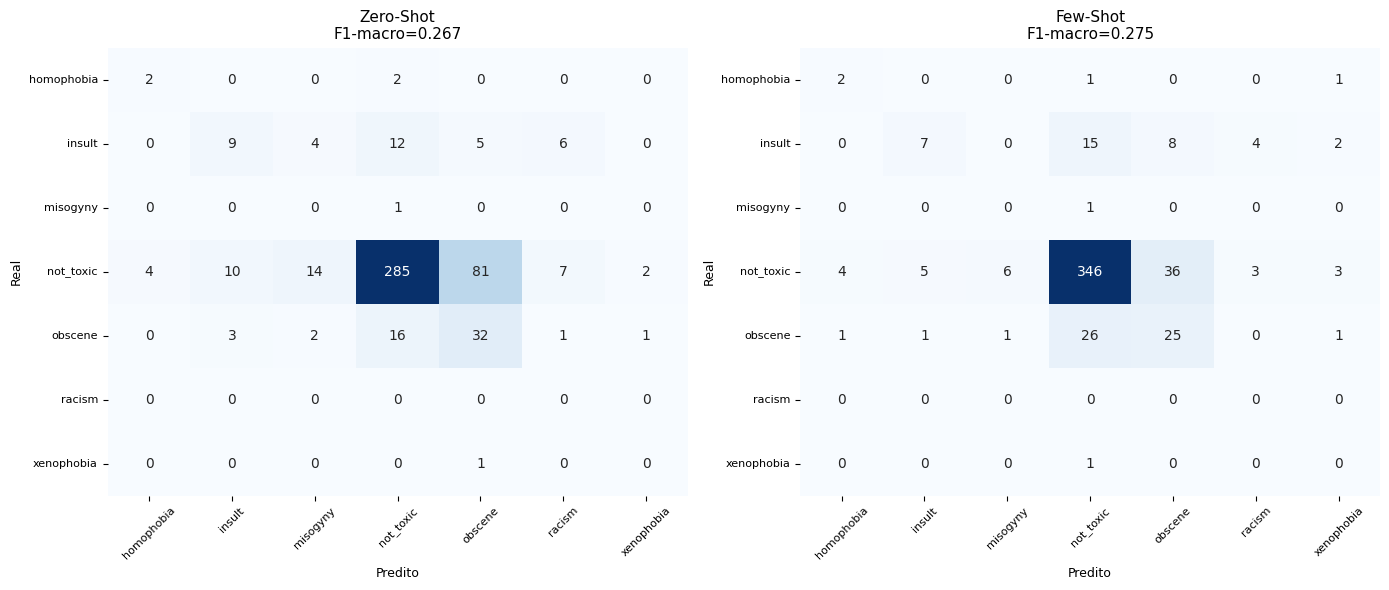

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (nome, df) in zip(axes, experimentos.items()):
    y_true = df["label"].to_list()
    y_pred = df["predicao"].to_list()
    cm = confusion_matrix(y_true, y_pred, labels=CATEGORIAS)
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=CATEGORIAS, yticklabels=CATEGORIAS,
                cmap="Blues", ax=ax, cbar=False)
    ax.set_xlabel("Predito", fontsize=9)
    ax.set_ylabel("Real", fontsize=9)
    ax.set_title(f"{NOMES_DISPLAY[nome]}\nF1-macro={metricas[nome]['f1_macro']:.3f}", fontsize=11)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", rotation=0,  labelsize=8)

plt.tight_layout()
plt.savefig("../results/confusion_matrices.png", dpi=150)
plt.show()

## Latência média por estratégia

In [6]:
print(f"{'Estratégia':<12} {'Tokens/s médio':>16} {'Tempo total (s)':>16}")
print("-" * 46)
for nome, df in experimentos.items():
    tps = df["tokens_s"].mean()
    total = df["latencia_s"].max()
    print(f"{nome:<12} {tps:>16.1f} {total:>16.0f}")
    metricas[nome]["tokens_s_medio"] = round(tps, 1)
    metricas[nome]["tempo_total_s"]  = round(float(total), 1)

Estratégia     Tokens/s médio  Tempo total (s)
----------------------------------------------
zero_shot               106.7              140
few_shot                107.0              187


## Salvar resumo

In [7]:
with open("../results/metrics_summary.json", "w", encoding="utf-8") as f:
    json.dump(metricas, f, ensure_ascii=False, indent=2)

print("Salvo em results/metrics_summary.json")
print("\nRESUMO FINAL")
print("=" * 40)
for nome, m in metricas.items():
    print(f"{nome:<12}  F1-macro={m['f1_macro']:.4f}")

Salvo em results/metrics_summary.json

RESUMO FINAL
zero_shot     F1-macro=0.2673
few_shot      F1-macro=0.2750


In [8]:
base = experimentos["zero_shot"].select(["text", "label"])

df_comparacao = base
for nome, df in experimentos.items():
    df_comparacao = df_comparacao.with_columns(
        df["predicao"].alias(f"pred_{nome}"),
        df["resposta_raw"].alias(f"resposta_{nome}"),
    )

df_comparacao.write_csv("../results/predictions_comparison.csv")
print("Salvo em results/predictions_comparison.csv")
print(df_comparacao.head(5))

Salvo em results/predictions_comparison.csv
shape: (5, 6)
┌──────────────────┬────────┬────────────────┬──────────────────┬───────────────┬──────────────────┐
│ text             ┆ label  ┆ pred_zero_shot ┆ resposta_zero_sh ┆ pred_few_shot ┆ resposta_few_sho │
│ ---              ┆ ---    ┆ ---            ┆ ot               ┆ ---           ┆ t                │
│ str              ┆ str    ┆ str            ┆ ---              ┆ str           ┆ ---              │
│                  ┆        ┆                ┆ str              ┆               ┆ str              │
╞══════════════════╪════════╪════════════════╪══════════════════╪═══════════════╪══════════════════╡
│ @user @user      ┆ insult ┆ misogyny       ┆ MISOGYNY         ┆ xenophobia    ┆ XENOPHOBIA       │
│ @user Se não     ┆        ┆                ┆                  ┆               ┆                  │
│ fosse…           ┆        ┆                ┆                  ┆               ┆                  │
│ vejo vídeos como ┆ insult ┆ rac

In [9]:
rows = []
for nome, m in metricas.items():
    for cat in CATEGORIAS:
        pc = m["per_class"].get(cat, {})
        rows.append({
            "estrategia":   nome,
            "categoria":    cat,
            "f1":           pc.get("f1", 0.0),
            "precision":    pc.get("precision", 0.0),
            "recall":       pc.get("recall", 0.0),
            "support":      pc.get("support", 0),
            "f1_macro":     m["f1_macro"],
            "f1_weighted":  m["f1_weighted"],
        })

df_metrics = pl.DataFrame(rows)
df_metrics.write_csv("../results/metrics_per_strategy.csv")
print("Salvo em results/metrics_per_strategy.csv")
print(df_metrics)

Salvo em results/metrics_per_strategy.csv
shape: (14, 8)
┌────────────┬────────────┬────────┬───────────┬────────┬─────────┬──────────┬─────────────┐
│ estrategia ┆ categoria  ┆ f1     ┆ precision ┆ recall ┆ support ┆ f1_macro ┆ f1_weighted │
│ ---        ┆ ---        ┆ ---    ┆ ---       ┆ ---    ┆ ---     ┆ ---      ┆ ---         │
│ str        ┆ str        ┆ f64    ┆ f64       ┆ f64    ┆ i64     ┆ f64      ┆ f64         │
╞════════════╪════════════╪════════╪═══════════╪════════╪═════════╪══════════╪═════════════╡
│ zero_shot  ┆ homophobia ┆ 0.4    ┆ 0.3333    ┆ 0.5    ┆ 4       ┆ 0.2673   ┆ 0.705       │
│ zero_shot  ┆ insult     ┆ 0.3103 ┆ 0.4091    ┆ 0.25   ┆ 36      ┆ 0.2673   ┆ 0.705       │
│ zero_shot  ┆ misogyny   ┆ 0.0    ┆ 0.0       ┆ 0.0    ┆ 1       ┆ 0.2673   ┆ 0.705       │
│ zero_shot  ┆ not_toxic  ┆ 0.7928 ┆ 0.9019    ┆ 0.7072 ┆ 403     ┆ 0.2673   ┆ 0.705       │
│ zero_shot  ┆ obscene    ┆ 0.3678 ┆ 0.2689    ┆ 0.5818 ┆ 55      ┆ 0.2673   ┆ 0.705       │
│ …          